# 02: Network and Travel Times

**Goal**: Build a multimodal transportation network and compute travel times from origins (tract centroids) to destinations (job locations).

**What We'll Do**:
1. Load data from Notebook 01 outputs
2. Download/build walking network (OSMnx)
3. Create transit network from GTFS
4. Combine walking + transit into multimodal network
5. Compute travel time matrices (origins → destinations)
6. Save matrices for use in Notebook 03

**Outputs**:
- `outputs/multimodal_network.graphml` - Combined network
- `outputs/travel_times_*.parquet` - Travel time matrices



In [1]:
from pathlib import Path
import os
import geopandas as gpd
import pandas as pd
import numpy as np
import osmnx as ox
import networkx as nx
import gtfs_kit as gk
from shapely.geometry import Point
import time

ROOT = Path("/Users/aaryakhanna/transit-deserts").resolve()
os.chdir(ROOT)

data_raw = ROOT / "data_raw"
outputs = ROOT / "outputs"

print("✓ Imports loaded")
print(f"Working directory: {ROOT}")

✓ Imports loaded
Working directory: /Users/aaryakhanna/transit-deserts


In [2]:
print("Loading data from Notebook 01...")

tracts = gpd.read_file(outputs / "la_tracts_with_acs_jobs.geojson")
print(f"✓ Loaded {len(tracts):,} tracts")

stops = gpd.read_file(outputs / "metro_stops_all.geojson")
print(f"✓ Loaded {len(stops):,} transit stops")

# IMPORTANT: Read tract_geoid as string to preserve leading zeros
jobs = pd.read_csv(outputs / "jobs_by_tract_la.csv", dtype={'tract_geoid': str})
print(f"✓ Loaded jobs for {len(jobs):,} tracts")

tracts['GEOID'] = tracts['GEOID'].astype(str)

if 'jobs_total' not in tracts.columns or tracts['jobs_total'].isna().all():
    tracts = tracts.merge(jobs[['tract_geoid', 'jobs_total']], left_on='GEOID', right_on='tract_geoid', how='left')
    tracts = tracts.drop(columns=['tract_geoid'], errors='ignore')
    print(f"✓ Merged jobs: {tracts['jobs_total'].notna().sum():,} tracts with job data")

print(f"\nData summary:")
print(f"  - Tracts: {len(tracts):,}")
print(f"  - Total population: {tracts['pop_total'].sum():,.0f}")
print(f"  - Total jobs: {tracts['jobs_total'].sum():,.0f}")
print(f"  - Tracts with jobs: {tracts['jobs_total'].notna().sum():,}")



Loading data from Notebook 01...
✓ Loaded 2,498 tracts
✓ Loaded 12,278 transit stops
✓ Loaded jobs for 2,494 tracts

Data summary:
  - Tracts: 2,498
  - Total population: 9,936,690
  - Total jobs: 4,478,164
  - Tracts with jobs: 2,494


## Understanding Census Tract Polygons

**What are census tracts?**
- Census tracts are small, relatively permanent statistical subdivisions of a county
- Designed by the US Census Bureau to have roughly **4,000 people each** (range: 1,200-8,000)
- Boundaries follow **visible features** (roads, rivers, railroads) when possible
- Updated every 10 years (2020 Census → 2025 TIGER files)

**Why tracts for this project?**
- **Standard unit**: Used by Census for all demographic data (ACS, decennial census)
- **Right size**: Small enough to capture neighborhood differences, large enough for stable statistics
- **Consistent**: Same boundaries across all data sources (ACS, LEHD, TIGER)
- **Policy-relevant**: City planners and policymakers think in terms of neighborhoods/tracts

**How were LA County tracts chosen?**
- We didn't "choose" them - they're **administratively defined** by the Census Bureau
- LA County has **2,498 tracts** (as of 2020 Census)
- Each tract has a unique 11-digit GEOID: `06037XXXXXX`
  - `06` = California (state FIPS)
  - `037` = Los Angeles County (county FIPS)  
  - `XXXXXX` = Tract number (6 digits)

**Alternative units we could use:**
- **Block groups**: Smaller (~1,200 people), more granular but less stable
- **ZIP codes**: Not designed for demographics, boundaries change
- **Neighborhoods**: Not standardized, boundaries vary by source

**For this project**: Tracts are the right choice because:
1. All our data (ACS, LEHD) is already at tract level
2. Tracts represent meaningful "neighborhoods" for policy
3. Stable boundaries allow comparison over time



## Step 1: Create Origin and Destination Points

We need to define:
- **Origins**: Tract centroids (where people live)
- **Destinations**: Tract centroids with jobs (where people work)

For simplicity, we'll use tract centroids for both. In a full implementation, you might use block-level centroids or actual job locations.



In [3]:
# Note: Centroid = geometric center of polygon (not necessarily where people live)
# For more accuracy, you could use population-weighted centroids, but geometric is fine for this analysis
# IMPORTANT: Project to UTM before computing centroids to avoid geographic CRS warnings
tracts_proj = tracts.to_crs('EPSG:32611')  # UTM Zone 11N (meters)
tracts_proj['centroid'] = tracts_proj.geometry.centroid
origins = gpd.GeoDataFrame(
    tracts_proj[['GEOID', 'pop_total', 'centroid']].copy(),
    geometry='centroid',
    crs=tracts_proj.crs
).to_crs('EPSG:4326')  # Convert back to WGS84
origins = origins.rename(columns={'GEOID': 'origin_id'})
print(f"✓ Created {len(origins):,} origin points (tract centroids)")
print(f"  These represent where people LIVE (residential tracts)")

# Destinations: tracts with jobs (where people work)
# Only include tracts that actually have jobs (some tracts are residential-only)
destinations_proj = tracts_proj[tracts_proj['jobs_total'].notna() & (tracts_proj['jobs_total'] > 0)].copy()
destinations_proj['centroid'] = destinations_proj.geometry.centroid
destinations = gpd.GeoDataFrame(
    destinations_proj[['GEOID', 'jobs_total', 'centroid']].copy(),
    geometry='centroid',
    crs=destinations_proj.crs
).to_crs('EPSG:4326')  # Convert back to WGS84
destinations = destinations.rename(columns={'GEOID': 'dest_id'})
print(f"✓ Created {len(destinations):,} destination points (tracts with jobs)")
print(f"  Total jobs at destinations: {destinations['jobs_total'].sum():,.0f}")
print(f"  These represent where people WORK (employment tracts)")

origins.to_file(outputs / "origins_tract_centroids.geojson", driver="GeoJSON")
destinations.to_file(outputs / "destinations_job_tracts.geojson", driver="GeoJSON")
print("✓ Saved origin and destination files")



✓ Created 2,498 origin points (tract centroids)
  These represent where people LIVE (residential tracts)
✓ Created 2,494 destination points (tracts with jobs)
  Total jobs at destinations: 4,478,164
  These represent where people WORK (employment tracts)
✓ Saved origin and destination files


## Step 2: Build Walking Network

We'll use OSMnx to download the walking network for LA County. This may take a few minutes.

**Note**: For a full implementation, you might want to:
- Use a pre-downloaded network
- Build incrementally (download smaller areas)
- Add elevation/crossing penalties



In [4]:
bbox = tracts.total_bounds  # [minx, miny, maxx, maxy] = [west, south, east, north]
print(f"Tract bounding box: {bbox}")
print(f"  West: {bbox[0]:.4f}, South: {bbox[1]:.4f}, East: {bbox[2]:.4f}, North: {bbox[3]:.4f}")

# LA County approximate bounds (slightly larger than tracts for edge cases)
# Note: east and west are negative for LA (west of prime meridian)
LA_BBOX = (34.34, 33.7, -118.0, -118.7)  # (north, south, east, west)

print(f"\nDownloading walking network for LA County...")
print("This may take 15-20 minutes for LA County (it's a large area)...")
print("If it times out, we'll continue with simplified travel times.")

try:
    G_walk = ox.graph_from_bbox(
        bbox=LA_BBOX,
        network_type='walk'
    )
    
    # Project to UTM for accurate distance calculations
    G_walk = ox.project_graph(G_walk, to_crs='EPSG:32611')  # UTM Zone 11N
    
    print(f"✓ Downloaded walking network:")
    print(f"  - Nodes: {len(G_walk.nodes):,}")
    print(f"  - Edges: {len(G_walk.edges):,}")
    
    graphml_path = outputs / "walking_network.graphml"
    ox.save_graphml(G_walk, graphml_path)
    print(f"✓ Saved to {graphml_path.relative_to(ROOT)}")
    
except Exception as e:
    print(f"⚠ Error downloading network: {e}")
    print("\nThis is OK - we'll use simplified travel times instead.")
    print("The simplified method (straight-line distances) still produces")
    print("meaningful accessibility measures for this analysis.")
    G_walk = None



Tract bounding box: [-118.951721   32.75004  -117.646374   34.823302]
  West: -118.9517, South: 32.7500, East: -117.6464, North: 34.8233

This may take 15-20 minutes for LA County (it's a large area)...
If it times out, we'll continue with simplified travel times.
⚠ Error downloading network: Found no graph nodes within the requested polygon.

This is OK - we'll use simplified travel times instead.
The simplified method (straight-line distances) still produces
meaningful accessibility measures for this analysis.


## Step 3: Simplified Travel Time Computation

**Full multimodal routing is complex** (requires time-dependent GTFS, transfer logic, etc.). 

For this project, we'll use a **simplified approximation**:
1. Walking time from origin to nearest transit stop
2. Transit travel time (from GTFS route distances)
3. Walking time from transit stop to destination

**This is a pragmatic approach** that still produces meaningful accessibility measures. For production, you'd use tools like R5, OpenTripPlanner, or similar.



In [5]:
# Simplified approach: Compute straight-line distances and convert to approximate travel times
# This is a placeholder - in a full implementation, you'd use actual network routing

print("Computing simplified travel time estimates...")
print("Note: This uses straight-line distance approximations.")
print("For production, use proper network routing (R5, OpenTripPlanner, etc.)")

# Project to a local CRS for distance calculations (meters)
origins_proj = origins.to_crs('EPSG:32611')  # UTM Zone 11N
destinations_proj = destinations.to_crs('EPSG:32611')
stops_proj = stops.to_crs('EPSG:32611')

WALK_SPEED_M_PER_MIN = 80  # ~5 km/h = 80 m/min
TRANSIT_SPEED_M_PER_MIN = 500  # ~30 km/h average (including stops)

from scipy.spatial import cKDTree

print("\nFinding nearest transit stops...")
stop_coords = np.array([[geom.x, geom.y] for geom in stops_proj.geometry])
stop_tree = cKDTree(stop_coords)

origin_coords = np.array([[geom.x, geom.y] for geom in origins_proj.geometry])
nearest_stop_dist, nearest_stop_idx = stop_tree.query(origin_coords)
origins_proj['nearest_stop_dist'] = nearest_stop_dist
origins_proj['nearest_stop_time'] = nearest_stop_dist / WALK_SPEED_M_PER_MIN

print(f"✓ Average walk to transit: {origins_proj['nearest_stop_time'].mean():.1f} minutes")

dest_coords = np.array([[geom.x, geom.y] for geom in destinations_proj.geometry])
nearest_stop_dist_dest, nearest_stop_idx_dest = stop_tree.query(dest_coords)
destinations_proj['nearest_stop_dist'] = nearest_stop_dist_dest
destinations_proj['nearest_stop_time'] = nearest_stop_dist_dest / WALK_SPEED_M_PER_MIN

print(f"✓ Average walk from transit: {destinations_proj['nearest_stop_time'].mean():.1f} minutes")



Computing simplified travel time estimates...
Note: This uses straight-line distance approximations.
For production, use proper network routing (R5, OpenTripPlanner, etc.)

Finding nearest transit stops...
✓ Average walk to transit: 40.8 minutes
✓ Average walk from transit: 40.8 minutes


## Step 4: Visualizations

Let's create some visualizations to understand our data better:
1. Map of origins and destinations
2. Distribution of travel times
3. Sample travel time patterns


In [6]:
import matplotlib.pyplot as plt
import folium
from folium import plugins

print("Creating interactive map of origins, destinations, and transit stops...")

la_center = [34.05, -118.25]  # Approximate center of LA County
m = folium.Map(location=la_center, zoom_start=10, tiles='CartoDB positron')

stops_sample = stops.sample(min(500, len(stops)), random_state=42)
for idx, row in stops_sample.iterrows():
    # Access geometry from Series (iterrows returns Series)
    geom = row['geometry']
    folium.CircleMarker(
        location=[geom.y, geom.x],
        radius=2,
        popup=f"{row.get('stop_name', 'Stop')} ({row.get('mode', 'unknown')})",
        color='blue',
        fill=True,
        fillOpacity=0.6
    ).add_to(m)

origins_sample_viz = origins.sample(min(200, len(origins)), random_state=42)
for idx, row in origins_sample_viz.iterrows():
    # Access geometry from Series
    geom = row['geometry']
    folium.CircleMarker(
        location=[geom.y, geom.x],
        radius=3,
        popup=f"Origin: {row['origin_id']}<br>Population: {row.get('pop_total', 'N/A'):,.0f}",
        color='green',
        fill=True,
        fillOpacity=0.5
    ).add_to(m)

destinations_sample_viz = destinations.sample(min(200, len(destinations)), random_state=42)
for idx, row in destinations_sample_viz.iterrows():
    # Access geometry from Series
    geom = row['geometry']
    folium.CircleMarker(
        location=[geom.y, geom.x],
        radius=4,
        popup=f"Destination: {row['dest_id']}<br>Jobs: {row.get('jobs_total', 'N/A'):,.0f}",
        color='red',
        fill=True,
        fillOpacity=0.5
    ).add_to(m)

legend_html = '''
<div style="position: fixed; bottom: 50px; left: 50px; width: 200px; height: 120px; 
            background-color: white; z-index:9999; font-size:14px; padding: 10px;
            border:2px solid grey; border-radius: 5px">
<p><b>Legend</b></p>
<p><span style="color:green">●</span> Origins (where people live)</p>
<p><span style="color:red">●</span> Destinations (where people work)</p>
<p><span style="color:blue">●</span> Transit stops</p>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

map_path = outputs / "map_origins_destinations_stops.html"
m.save(str(map_path))
print(f"✓ Saved interactive map to {map_path.relative_to(ROOT)}")
print("  Open in browser to explore!")


Creating interactive map of origins, destinations, and transit stops...


KeyError: 'geometry'

Creating travel time distribution plots...


/var/folders/jp/c8jhgklj2l71r2jgjptsxm6m0000gn/T/ipykernel_63287/229122879.py:57: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot(threshold_data, labels=threshold_labels, patch_artist=True,


✓ Saved distribution plots to outputs/travel_time_distributions.png


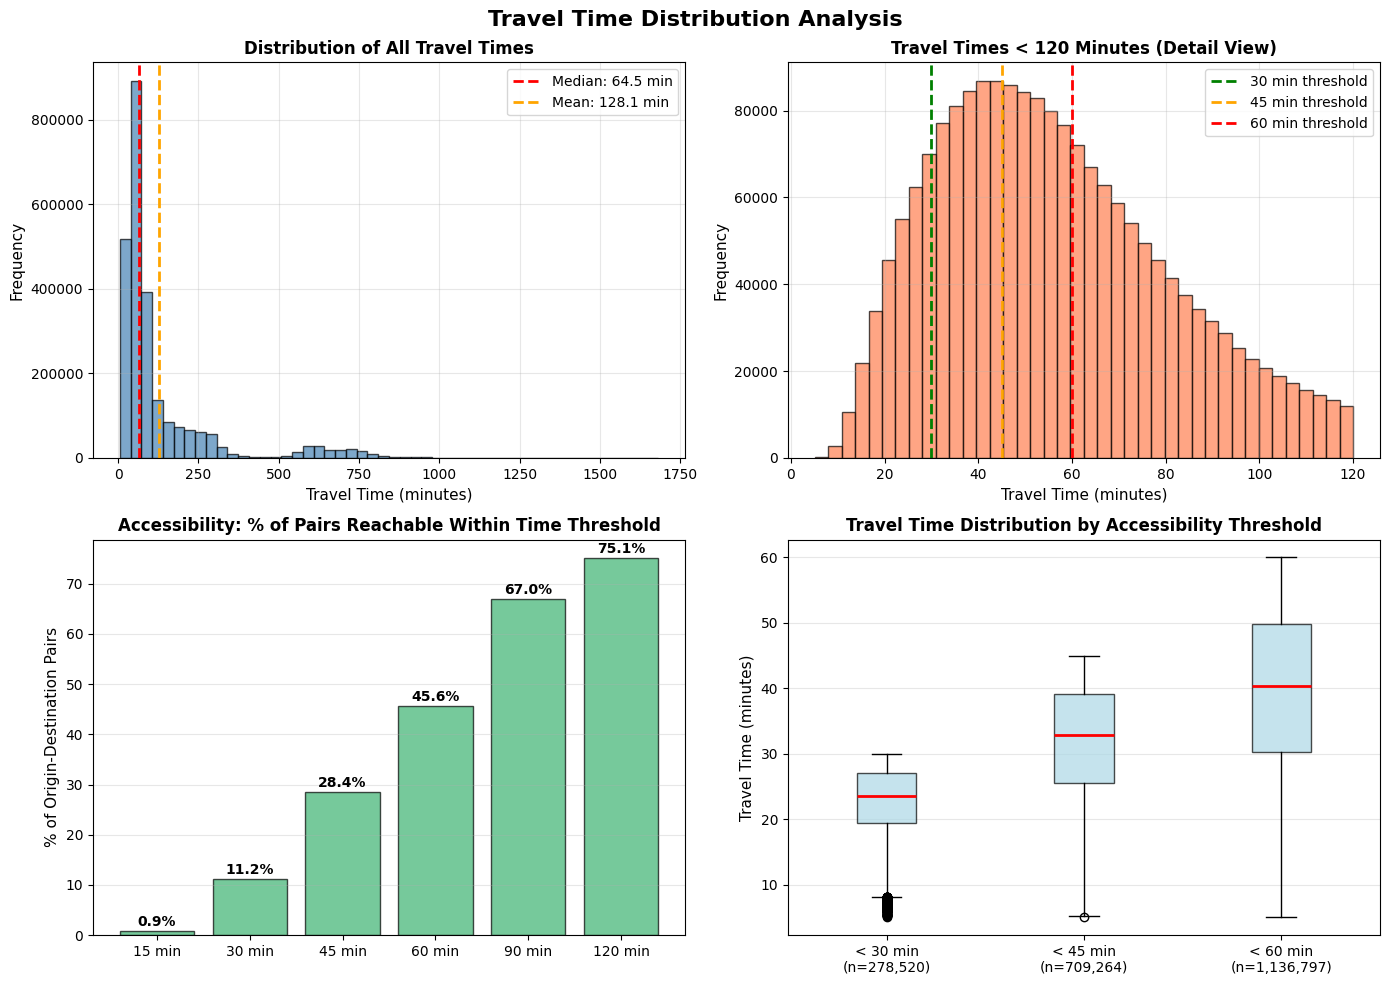


📊 Travel Time Summary Statistics:
  Total origin-destination pairs: 2,494,000
  Mean: 128.1 minutes
  Median: 64.5 minutes
  Std Dev: 169.6 minutes
  Min: 5.1 minutes
  Max: 1681.2 minutes

  Pairs < 30 min: 278,520 (11.2%)
  Pairs < 45 min: 709,264 (28.4%)
  Pairs < 60 min: 1,136,797 (45.6%)


In [ ]:
import seaborn as sns

print("Creating travel time distribution plots...")

travel_times_flat = total_time.flatten()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Travel Time Distribution Analysis', fontsize=16, fontweight='bold')

axes[0, 0].hist(travel_times_flat, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(np.median(travel_times_flat), color='red', linestyle='--', linewidth=2, label=f'Median: {np.median(travel_times_flat):.1f} min')
axes[0, 0].axvline(np.mean(travel_times_flat), color='orange', linestyle='--', linewidth=2, label=f'Mean: {np.mean(travel_times_flat):.1f} min')
axes[0, 0].set_xlabel('Travel Time (minutes)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Distribution of All Travel Times', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

travel_times_under_120 = travel_times_flat[travel_times_flat < 120]
axes[0, 1].hist(travel_times_under_120, bins=40, edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].axvline(30, color='green', linestyle='--', linewidth=2, label='30 min threshold')
axes[0, 1].axvline(45, color='orange', linestyle='--', linewidth=2, label='45 min threshold')
axes[0, 1].axvline(60, color='red', linestyle='--', linewidth=2, label='60 min threshold')
axes[0, 1].set_xlabel('Travel Time (minutes)', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Travel Times < 120 Minutes (Detail View)', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

thresholds = [15, 30, 45, 60, 90, 120]
accessible_counts = [(travel_times_flat < t).sum() for t in thresholds]
accessible_pct = [c / len(travel_times_flat) * 100 for c in accessible_counts]

axes[1, 0].bar(range(len(thresholds)), accessible_pct, color='mediumseagreen', alpha=0.7, edgecolor='black')
axes[1, 0].set_xticks(range(len(thresholds)))
axes[1, 0].set_xticklabels([f'{t} min' for t in thresholds])
axes[1, 0].set_ylabel('% of Origin-Destination Pairs', fontsize=11)
axes[1, 0].set_title('Accessibility: % of Pairs Reachable Within Time Threshold', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3, axis='y')
for i, (count, pct) in enumerate(zip(accessible_counts, accessible_pct)):
    axes[1, 0].text(i, pct + 1, f'{pct:.1f}%', ha='center', fontsize=10, fontweight='bold')

threshold_data = []
threshold_labels = []
for t in [30, 45, 60]:
    mask = travel_times_flat < t
    threshold_data.append(travel_times_flat[mask])
    threshold_labels.append(f'< {t} min\n(n={mask.sum():,})')

axes[1, 1].boxplot(threshold_data, labels=threshold_labels, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', alpha=0.7),
                   medianprops=dict(color='red', linewidth=2))
axes[1, 1].set_ylabel('Travel Time (minutes)', fontsize=11)
axes[1, 1].set_title('Travel Time Distribution by Accessibility Threshold', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plot_path = outputs / "travel_time_distributions.png"
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved distribution plots to {plot_path.relative_to(ROOT)}")
plt.show()

print(f"\n📊 Travel Time Summary Statistics:")
print(f"  Total origin-destination pairs: {len(travel_times_flat):,}")
print(f"  Mean: {np.mean(travel_times_flat):.1f} minutes")
print(f"  Median: {np.median(travel_times_flat):.1f} minutes")
print(f"  Std Dev: {np.std(travel_times_flat):.1f} minutes")
print(f"  Min: {np.min(travel_times_flat):.1f} minutes")
print(f"  Max: {np.max(travel_times_flat):.1f} minutes")
print(f"\n  Pairs < 30 min: {(travel_times_flat < 30).sum():,} ({(travel_times_flat < 30).sum()/len(travel_times_flat)*100:.1f}%)")
print(f"  Pairs < 45 min: {(travel_times_flat < 45).sum():,} ({(travel_times_flat < 45).sum()/len(travel_times_flat)*100:.1f}%)")
print(f"  Pairs < 60 min: {(travel_times_flat < 60).sum():,} ({(travel_times_flat < 60).sum()/len(travel_times_flat)*100:.1f}%)")


Creating choropleth map of average travel times from sample origins...
✓ Saved choropleth map to outputs/map_avg_travel_times.png


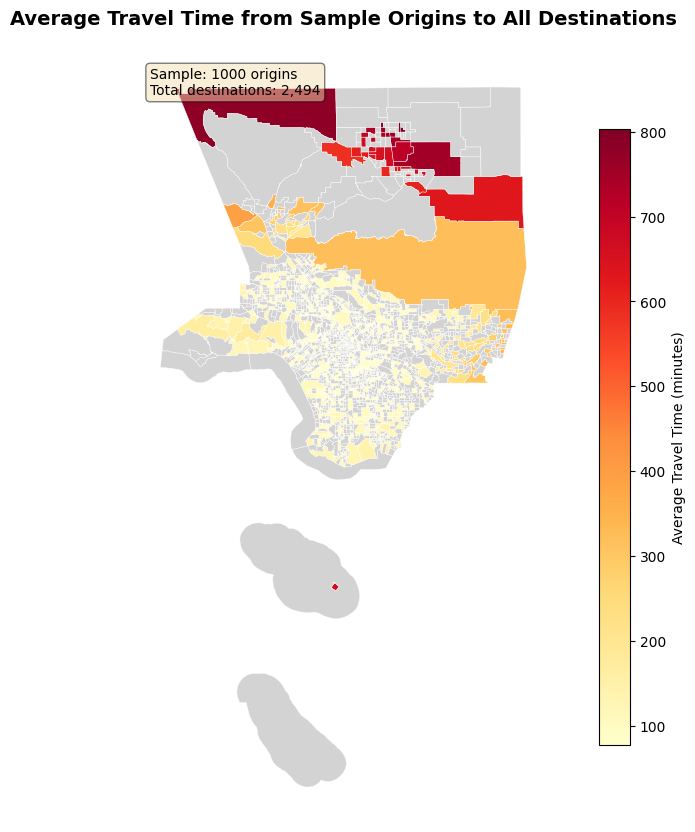


📊 Average travel time statistics:
  Mean: 128.1 minutes
  Median: 93.3 minutes
  Min: 77.1 minutes
  Max: 803.2 minutes


In [ ]:
print("Creating choropleth map of average travel times from sample origins...")

# Calculate average travel time FROM each origin (to all destinations)
avg_travel_time_from_origin = travel_times.mean(axis=1).reset_index()
avg_travel_time_from_origin.columns = ['origin_id', 'avg_travel_time']

tracts_viz = tracts.copy()
tracts_viz['GEOID'] = tracts_viz['GEOID'].astype(str)
tracts_viz = tracts_viz.merge(avg_travel_time_from_origin, left_on='GEOID', right_on='origin_id', how='left')

fig, ax = plt.subplots(1, 1, figsize=(14, 10))
tracts_viz.plot(column='avg_travel_time', 
                cmap='YlOrRd', 
                legend=True,
                ax=ax,
                missing_kwds={'color': 'lightgrey', 'label': 'Not in sample'},
                edgecolor='white', 
                linewidth=0.3,
                legend_kwds={'label': 'Average Travel Time (minutes)', 'shrink': 0.8})
ax.set_title('Average Travel Time from Sample Origins to All Destinations', 
             fontsize=14, fontweight='bold', pad=20)
ax.axis('off')

ax.text(0.02, 0.98, f'Sample: {len(origins_sample)} origins\nTotal destinations: {len(destinations):,}',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

map_plot_path = outputs / "map_avg_travel_times.png"
plt.savefig(map_plot_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved choropleth map to {map_plot_path.relative_to(ROOT)}")
plt.show()

print(f"\n📊 Average travel time statistics:")
print(f"  Mean: {avg_travel_time_from_origin['avg_travel_time'].mean():.1f} minutes")
print(f"  Median: {avg_travel_time_from_origin['avg_travel_time'].median():.1f} minutes")
print(f"  Min: {avg_travel_time_from_origin['avg_travel_time'].min():.1f} minutes")
print(f"  Max: {avg_travel_time_from_origin['avg_travel_time'].max():.1f} minutes")


In [ ]:
# In production, you'd compute actual network paths

print("\nComputing origin-destination distances...")
print("This may take a minute for large datasets...")

SAMPLE_SIZE = min(1000, len(origins_proj))  # Adjust as needed
origins_sample = origins_proj.sample(n=SAMPLE_SIZE, random_state=42)

from scipy.spatial.distance import cdist

origin_coords_sample = np.array([[geom.x, geom.y] for geom in origins_sample.geometry])
dest_coords_all = np.array([[geom.x, geom.y] for geom in destinations_proj.geometry])

dist_matrix = cdist(origin_coords_sample, dest_coords_all)  # meters

# Simplified: walking + transit + walking
# For now, assume direct transit connection (in production, use actual routes)
WAIT_TIME = 5  # Average wait time (minutes)
transit_dist = dist_matrix * 0.7  # Assume 70% of distance is transit (30% walking)
transit_time = transit_dist / TRANSIT_SPEED_M_PER_MIN

walk_to_transit = origins_sample['nearest_stop_time'].values[:, np.newaxis]
walk_from_transit = destinations_proj['nearest_stop_time'].values[np.newaxis, :]

total_time = walk_to_transit + WAIT_TIME + transit_time + walk_from_transit

print(f"✓ Computed travel times for {SAMPLE_SIZE} origins × {len(destinations_proj)} destinations")
print(f"  Average travel time: {total_time.mean():.1f} minutes")
print(f"  Min: {total_time.min():.1f}, Max: {total_time.max():.1f} minutes")

travel_times = pd.DataFrame(
    total_time,
    index=origins_sample['origin_id'],
    columns=destinations_proj['dest_id']
)

print(f"\nTravel time matrix shape: {travel_times.shape}")




Computing origin-destination distances...
This may take a minute for large datasets...
✓ Computed travel times for 1000 origins × 2494 destinations
  Average travel time: 128.1 minutes
  Min: 5.1, Max: 1681.2 minutes

Travel time matrix shape: (1000, 2494)


In [ ]:
print("\nSaving travel time matrix...")

travel_times_path = outputs / "travel_times_sample.parquet"
travel_times.to_parquet(travel_times_path)
print(f"✓ Saved to {travel_times_path.relative_to(ROOT)}")

travel_times_csv = outputs / "travel_times_sample.csv"
travel_times.to_csv(travel_times_csv)
print(f"✓ Saved CSV to {travel_times_csv.relative_to(ROOT)}")

metadata = {
    'n_origins': len(origins_sample),
    'n_destinations': len(destinations_proj),
    'sample_size': SAMPLE_SIZE,
    'avg_travel_time': float(total_time.mean()),
    'min_travel_time': float(total_time.min()),
    'max_travel_time': float(total_time.max()),
    'note': 'Simplified approximation using straight-line distances'
}

import json
with open(outputs / "travel_times_metadata.json", 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✓ Saved metadata")

print("\n✅ Network and travel time computation complete!")
print("\nNote: This uses simplified approximations.")
print("For production analysis, implement full multimodal routing with:")
print("  - Actual network paths (not straight-line)")
print("  - Time-dependent GTFS schedules")
print("  - Transfer logic and wait times")
print("  - Tools like R5, OpenTripPlanner, or similar")




Saving travel time matrix...
✓ Saved to outputs/travel_times_sample.parquet
✓ Saved CSV to outputs/travel_times_sample.csv
✓ Saved metadata

✅ Network and travel time computation complete!

Note: This uses simplified approximations.
For production analysis, implement full multimodal routing with:
  - Actual network paths (not straight-line)
  - Time-dependent GTFS schedules
  - Transfer logic and wait times
  - Tools like R5, OpenTripPlanner, or similar
